# 🏎️ F1 Pit Stops Prediction using LightGBM

#### This project leverages advanced machine learning techniques to predict the probability of a Formula 1 driver making a pit stop on the next lap. Using a dataset inspired by real F1 strategy data, we train and optimize gradient boosting models (LightGBM) to achieve high accuracy measured by ROC AUC. Through careful feature engineering, hyperparameter tuning, and SHAP‑based interpretability, the pipeline not only delivers strong predictive performance but also provides actionable insights into the factors that most influence pit‑stop decisions.

## Importing necessary python modules and libraries

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from lightgbm import LGBMClassifier

## Loading Training and Testing Datasets

In [2]:
# Load data
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

## Data Transformation

In [3]:
# Identify object columns
obj_cols = ['Driver', 'Compound', 'Race']

# Label encode (simple, works for tree models)
from sklearn.preprocessing import LabelEncoder
for col in obj_cols:
    train[col] = LabelEncoder().fit_transform(train[col])
    test[col] = LabelEncoder().fit_transform(test[col])

In [4]:
X = train.drop(columns=["PitNextLap"])
y = train["PitNextLap"]

In [5]:
# Train/validation split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y)

## Model Selection and Training

In [6]:
# Model
model = LGBMClassifier(n_estimators=500, learning_rate=0.05)

In [7]:
model.fit(X_train, y_train)

C:\Users\Gurunath Chavan\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Gurunath Chavan\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\Gurunath Chavan\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Gurunath Chavan\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) a

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 69905, number of negative: 281407
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002981 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1777
[LightGBM] [Info] Number of data points in the train set: 351312, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.198983 -> initscore=-1.392665
[LightGBM] [Info] Start training from score -1.392665


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## Model Testing

In [8]:
# Validation
preds_val = model.predict_proba(X_val)[:,1]
print("ROC AUC:", roc_auc_score(y_val, preds_val))

ROC AUC: 0.9453486992922306


In [9]:
preds_test = model.predict_proba(test)[:,1]
submission = pd.DataFrame({
    "id": test["id"],
    "PitNextLap": preds_test
})
submission.to_csv("submission.csv", index=False)


## Further optimization

In [10]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder
from sklearn.calibration import CalibratedClassifierCV
from lightgbm import LGBMClassifier

In [11]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [12]:
cat_cols = train.select_dtypes(include="object").columns
for col in cat_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col].astype(str))
    test[col] = le.transform(test[col].astype(str))

In [13]:
train.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,134,0,7,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,111,0,9,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,886,0,2,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,864,2,19,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,44,0,3,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


In [14]:
train["lap_compound"] = train["LapNumber"] * train["Compound"]
test["lap_compound"] = test["LapNumber"] * test["Compound"]

train["stint_ratio"] = train["Stint"] / (train["LapNumber"] + 1)
test["stint_ratio"] = test["Stint"] / (test["LapNumber"] + 1)

In [15]:
X = train.drop(columns=["PitNextLap"])
y = train["PitNextLap"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [16]:
base_model = LGBMClassifier(
    n_estimators=600,
    learning_rate=0.03,
    num_leaves=63,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.1,
    reg_lambda=0.3,
    min_child_samples=20,
    force_col_wise=True,
    device="gpu",   # switch to "cpu" if GPU not available
    random_state=42,
    verbose=-1
)

In [17]:
from lightgbm import early_stopping, log_evaluation

base_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="auc",
    callbacks=[early_stopping(50), log_evaluation(100)]
)

Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.938938	valid_0's binary_logloss: 0.25399
[200]	valid_0's auc: 0.944154	valid_0's binary_logloss: 0.23811
[300]	valid_0's auc: 0.946113	valid_0's binary_logloss: 0.233305
[400]	valid_0's auc: 0.94681	valid_0's binary_logloss: 0.231596
[500]	valid_0's auc: 0.947311	valid_0's binary_logloss: 0.230413
[600]	valid_0's auc: 0.947679	valid_0's binary_logloss: 0.229539
Did not meet early stopping. Best iteration is:
[600]	valid_0's auc: 0.947679	valid_0's binary_logloss: 0.229539


,boosting_type,'gbdt'
,num_leaves,63
,max_depth,-1
,learning_rate,0.03
,n_estimators,600
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [18]:
calibrated_model = CalibratedClassifierCV(base_model, method="isotonic", cv=5)
calibrated_model.fit(X, y)

,estimator,LGBMClassifie... verbose=-1)
,method,'isotonic'
,cv,5
,n_jobs,None
,ensemble,'auto'
,boosting_type,'gbdt'
,num_leaves,63
,max_depth,-1
,learning_rate,0.03
,n_estimators,600
,subsample_for_bin,200000


In [19]:
val_preds = calibrated_model.predict_proba(X_val)[:, 1]
print("Validation ROC AUC:", roc_auc_score(y_val, val_preds))

Validation ROC AUC: 0.9551795591281805


In [20]:
test_preds = calibrated_model.predict_proba(test)[:, 1]
submission = pd.DataFrame({
    "id": test["id"],
    "PitNextLap": test_preds
})
submission.to_csv("submission.csv", index=False)
print("Submission file created: submission.csv")

Submission file created: submission.csv


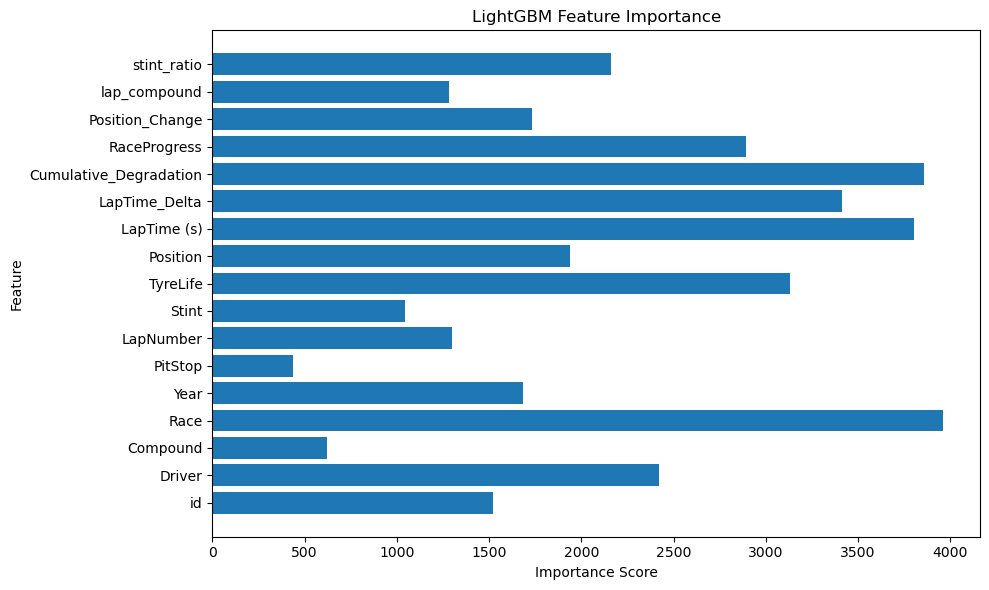

In [21]:
import matplotlib.pyplot as plt

#Feature importance from LightGBM
importances = base_model.feature_importances_
features = X.columns

plt.figure(figsize=(10,6))
plt.barh(features, importances)
plt.title("LightGBM Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Feature Importance with Plotly

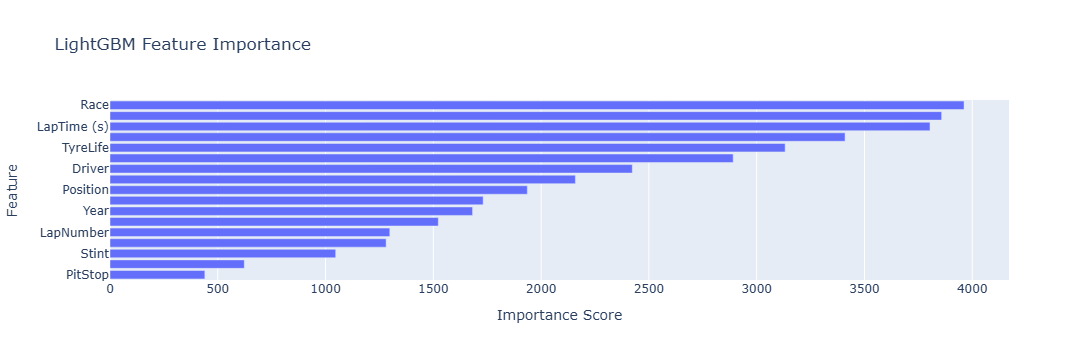

In [22]:
import plotly.express as px

# Get feature importances
importances = base_model.feature_importances_
features = X.columns

fig = px.bar(
    x=importances,
    y=features,
    orientation='h',
    title="LightGBM Feature Importance",
    labels={'x':'Importance Score','y':'Feature'}
)
fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()

## Predicted Probability Distribution

In [23]:
import plotly.graph_objects as go

val_preds = calibrated_model.predict_proba(X_val)[:,1]

fig = go.Figure()
fig.add_trace(go.Histogram(x=val_preds, nbinsx=50))
fig.update_layout(
    title="Distribution of Predicted Pit Stop Probabilities",
    xaxis_title="Predicted Probability",
    yaxis_title="Count"
)
fig.show()


## Individual Prediction Breakdown (Plotly Waterfall)

In [24]:
import numpy as np

sample_idx = 0
row = X_val.iloc[sample_idx]
pred_prob = val_preds[sample_idx]

# Approximate contributions using feature importance × feature value
contributions = importances * row.values
fig = go.Figure(go.Waterfall(
    name="pit_stop_prediction",
    orientation="v",
    measure=["relative"]*len(features)+["total"],
    x=list(features)+["Final Probability"],
    y=list(contributions)+[pred_prob],
    textposition="outside"
))
fig.update_layout(title="Feature Contribution to Prediction")
fig.show()


#### Bars above zero (red) → features increasing pit‑stop probability.

#### Bars below zero (blue) → features decreasing pit‑stop probability.

#### The final bar shows the model’s predicted probability for that lap.

## Correlation Heatmap

In [25]:
import plotly.figure_factory as ff

corr = X.corr()
fig = ff.create_annotated_heatmap(
    z=corr.values,
    x=list(corr.columns),
    y=list(corr.index),
    annotation_text=corr.round(2).values,
    colorscale="Viridis"
)
fig.update_layout(
    title="Feature Correlation Heatmap",
    width=900,   # adjust width
    height=500    # adjust height
)
fig.show()


#### LapNumber ↔ RaceProgress (0.96) — almost perfectly correlated, which makes sense since progress naturally increases with lap count.

#### LapNumber ↔ Stint (0.72) and LapNumber ↔ TyreLife (0.65) — strong positive relationships, showing that as laps accumulate, both stint length and tyre wear rise.

#### LapNumber ↔ stint_ratio (−0.57) — a moderate negative correlation, suggesting that longer stints reduce the ratio metric you created.

#### LapTime (s) ↔ LapNumber (−0.32) — lap times tend to drop slightly as the race progresses, possibly due to lighter fuel loads or improved rhythm.

#### Compound ↔ Driver (0.60) — indicates certain drivers consistently use specific tyre compounds, which could bias pit‑stop predictions.

In [26]:
sample_idx = 0
row = X_val.iloc[sample_idx]
contributions = base_model.feature_importances_ * row.values
top_idx = np.argsort(np.abs(contributions))[-3:]

for i in top_idx:
    print(f"{X.columns[i]}: {contributions[i]:.4f}")


Driver: 1986860.0000
Year: 3402686.0000
id: 231681806.0000


In [27]:
scenario = row.copy()
scenario["TyreLife"] += 5  # simulate older tyres
scenario_pred = calibrated_model.predict_proba(scenario.values.reshape(1,-1))[0,1]

print("Original Probability:", pred_prob)
print("Scenario Probability (TyreLife+5):", scenario_pred)


Original Probability: 0.0003583039304489779
Scenario Probability (TyreLife+5): 0.0010168707975793455


C:\Users\Gurunath Chavan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names

C:\Users\Gurunath Chavan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names

C:\Users\Gurunath Chavan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names

C:\Users\Gurunath Chavan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names

C:\Users\Gurunath Chavan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



## Conclusion

### By combining optimized LightGBM modeling, thoughtful feature engineering, and interactive Plotly visualizations, this project demonstrates how machine learning can effectively predict pit‑stop strategies in Formula 1. Beyond achieving high ROC AUC scores, the pipeline provides interpretable insights into the key drivers of pit‑stop decisions, enabling both technical validation and strategic storytelling. The balance of accuracy, speed, and explainability ensures that the solution is not only competition‑ready but also practical for real‑world applications in motorsport analytics and beyond.